# NST2062 Technical Assignment #2 (2026)
## Investigating Minds and Machines From the Inside

**Total: 100 points (80 + 20 bonus)**

**Estimated time: 4–8 hours**

Dear Friend, this assignment has two problems. Both use large language models as the **object of study** — not just as a tool. You will probe what models know, how they express (or fail to express) uncertainty, and how the reward signal shapes their outputs.

### Ground Rules
- You **may** use LLMs (ChatGPT, Claude, Copilot, etc.) to help you write code, debug, and brainstorm. This is expected.
- You **must** document every LLM interaction that materially shaped your solution in the **Metacognitive Reflection** sections. Prompts, what worked, what didn't, what you had to fix.
- The reflection sections are **graded** and cannot be generated by an LLM. They must be in your own voice.
- Submit: this completed notebook (.ipynb) with all cells run + outputs visible.

---

## Problem 1: Calibration & Confidence — Do Models Know What They Don't Know?
### (45 points + 10 bonus)

**Course connections**: Decisions Under Uncertainty (Bayesian brain, calibration, overconfidence), Representation (what's encoded in embedding space), Learning & Reward (RLHF shapes confidence).

**The question**: When an LLM says it's confident, should you believe it? You saw in the Calibration Game (Lecture 4) that humans are overconfident on hard questions and underconfident on easy ones. LLMs are overconfident uniformly — because RLHF rewarded confident-sounding answers. In this problem, you'll measure this empirically.

---

### Part A: Build a Calibration Dataset (10 points)

Create a dataset of **50 factual questions** with known ground-truth answers. Your dataset must include:
- 10 **easy** questions (most people would know: e.g., "What is the capital of France?")
- 15 **medium** questions (educated guess: e.g., "How many bones in the adult human body?")
- 15 **hard** questions (specialist knowledge: e.g., "What year was the Rescorla-Wagner model published?")
- 10 **unanswerable/trick** questions (no clear answer, or trick framing: e.g., "What is the weight of the colour blue?")

For each question, record:
- The question text
- The ground-truth answer (or "unanswerable" for trick questions)
- The difficulty category (easy / medium / hard / unanswerable)

**Tip**: Mix domains — some from the course content (neuroscience, AI), some general knowledge, some current events. The mix matters for the analysis.

In [5]:
# Part A: Build a 50-question calibration dataset
import re
import json
import math
import os
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

API_BASE_URL = os.environ.get("API_BASE_URL", "https://openrouter.ai/api/v1")
DEFAULT_MODEL = os.environ.get("DEFAULT_MODEL", "qwen/qwen3.6-plus:free")
API_TOKEN = os.environ.get("API_KEY", None)
if API_TOKEN is None:
    raise RuntimeError("Please set the API_KEY environment variable to your OpenRouter API token.")
OUTPUT_FOLDER_1 = Path("part1_outputs")
if not OUTPUT_FOLDER_1.exists():
    print(f"Creating output folder at {OUTPUT_FOLDER_1}")
    OUTPUT_FOLDER_1.mkdir()
print(f"Using API at {API_BASE_URL} with model {DEFAULT_MODEL}")

sns.set_theme(style="whitegrid")

questions = [
    # EASY (10)
    {"question": "What is the capital of France?", "answer": "Paris", "difficulty": "easy"},
    {"question": "How many days are there in a week?", "answer": "7", "difficulty": "easy"},
    {"question": "Which planet is known as the Red Planet?", "answer": "Mars", "difficulty": "easy"},
    {"question": "What gas do plants primarily absorb from the atmosphere for photosynthesis?", "answer": "Carbon dioxide", "difficulty": "easy"},
    {"question": "Who wrote 'Romeo and Juliet'?", "answer": "William Shakespeare", "difficulty": "easy"},
    {"question": "What is the largest ocean on Earth?", "answer": "Pacific Ocean", "difficulty": "easy"},
    {"question": "What is H2O commonly called?", "answer": "Water", "difficulty": "easy"},
    {"question": "Which continent is Egypt in?", "answer": "Africa", "difficulty": "easy"},
    {"question": "What is 9 x 9?", "answer": "81", "difficulty": "easy"},
    {"question": "What instrument has keys, pedals, and strings and is often found in concert halls?", "answer": "Piano", "difficulty": "easy"},

    # MEDIUM (15)
    {"question": "How many bones are in the adult human body?", "answer": "206", "difficulty": "medium"},
    {"question": "In which year did the Berlin Wall fall?", "answer": "1989", "difficulty": "medium"},
    {"question": "What is the chemical symbol for gold?", "answer": "Au", "difficulty": "medium"},
    {"question": "Who proposed the laws of motion and universal gravitation?", "answer": "Isaac Newton", "difficulty": "medium"},
    {"question": "What is the smallest prime number?", "answer": "2", "difficulty": "medium"},
    {"question": "Which blood type is known as the universal donor for red blood cells?", "answer": "O negative", "difficulty": "medium"},
    {"question": "What does HTTP stand for?", "answer": "Hypertext Transfer Protocol", "difficulty": "medium"},
    {"question": "Which scientist is associated with natural selection?", "answer": "Charles Darwin", "difficulty": "medium"},
    {"question": "What is the capital of Canada?", "answer": "Ottawa", "difficulty": "medium"},
    {"question": "How many players are on a soccer team on the field at one time?", "answer": "11", "difficulty": "medium"},
    {"question": "Which lobe of the brain is most associated with vision?", "answer": "Occipital lobe", "difficulty": "medium"},
    {"question": "In machine learning, what does overfitting mean?", "answer": "Learning training data too specifically and generalizing poorly", "difficulty": "medium"},
    {"question": "What is the SI unit of electric current?", "answer": "Ampere", "difficulty": "medium"},
    {"question": "What does GPU stand for?", "answer": "Graphics Processing Unit", "difficulty": "medium"},
    {"question": "Which country hosted the 2016 Summer Olympics?", "answer": "Brazil", "difficulty": "medium"},

    # HARD (15)
    {"question": "In what year was the Rescorla-Wagner model published?", "answer": "1972", "difficulty": "hard"},
    {"question": "Who introduced the concept of prediction error minimization in the Free Energy Principle framework?", "answer": "Karl Friston", "difficulty": "hard"},
    {"question": "What is the main neurotransmitter released by most excitatory cortical pyramidal neurons?", "answer": "Glutamate", "difficulty": "hard"},
    {"question": "What does BOLD stand for in fMRI?", "answer": "Blood-oxygen-level-dependent", "difficulty": "hard"},
    {"question": "Which optimization algorithm uses first and second moments of gradients and is widely used in deep learning?", "answer": "Adam", "difficulty": "hard"},
    {"question": "What is the approximate wavelength range of visible light in nanometers?", "answer": "About 380 to 700 nm", "difficulty": "hard"},
    {"question": "Which theorem states that no compression algorithm can compress all possible inputs?", "answer": "No Free Lunch theorem for lossless compression", "difficulty": "hard"},
    {"question": "What is the default network in neuroscience primarily associated with?", "answer": "Internally directed cognition and self-referential thought", "difficulty": "hard"},
    {"question": "What does KL in KL divergence stand for?", "answer": "Kullback-Leibler", "difficulty": "hard"},
    {"question": "Which architecture introduced self-attention as a central mechanism in sequence modeling?", "answer": "Transformer", "difficulty": "hard"},
    {"question": "What is the asymptotic time complexity of Dijkstra's algorithm using a binary heap?", "answer": "O((V+E) log V)", "difficulty": "hard"},
    {"question": "In Bayesian terms, what is the quantity proportional to likelihood times prior?", "answer": "Posterior", "difficulty": "hard"},
    {"question": "What is the pKa of carbonic acid's first dissociation in water at room temperature (approx.)?", "answer": "About 6.35", "difficulty": "hard"},
    {"question": "Which paper introduced the term 'attention is all you need'?", "answer": "Attention Is All You Need (Vaswani et al., 2017)", "difficulty": "hard"},
    {"question": "Which metric-learning loss uses triplets of anchor, positive, and negative examples?", "answer": "Triplet loss", "difficulty": "hard"},

    # UNANSWERABLE/TRICK (10)
    {"question": "What is the exact weight of the color blue?", "answer": "unanswerable", "difficulty": "unanswerable"},
    {"question": "What did Julius Caesar eat for breakfast on his 33rd birthday?", "answer": "unanswerable", "difficulty": "unanswerable"},
    {"question": "What is the best song ever written, objectively?", "answer": "unanswerable", "difficulty": "unanswerable"},
    {"question": "How many thoughts did you have yesterday at 3:17 PM?", "answer": "unanswerable", "difficulty": "unanswerable"},
    {"question": "What is the smell of number seven in SI units?", "answer": "unanswerable", "difficulty": "unanswerable"},
    {"question": "Which came first in all possible universes, the chicken or the egg?", "answer": "unanswerable", "difficulty": "unanswerable"},
    {"question": "What will be the exact global temperature at noon 100 years from today?", "answer": "unanswerable", "difficulty": "unanswerable"},
    {"question": "What is the one true meaning of life for every human?", "answer": "unanswerable", "difficulty": "unanswerable"},
    {"question": "Which single economic policy guarantees prosperity forever?", "answer": "unanswerable", "difficulty": "unanswerable"},
    {"question": "Who was objectively the greatest thinker in all of history by universal metric?", "answer": "unanswerable", "difficulty": "unanswerable"},
]

df_questions = pd.DataFrame(questions)
assert len(df_questions) == 50, f"Expected 50 questions, got {len(df_questions)}"
print(df_questions["difficulty"].value_counts())
display(df_questions.head(10))

# Save for downstream cells
out_dir = Path(f"{OUTPUT_FOLDER_1}")
out_dir.mkdir(exist_ok=True)
df_questions.to_csv(out_dir / "questions.csv", index=False)
print("Saved:", out_dir / "questions.csv")


def normalize_text(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9\s\-\.]+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text


def call_ai_raw(system_prompt: str, user_message: str, model=None, temperature: float = 0.2) -> str:
    from openai import OpenAI

    base_url = API_BASE_URL
    chosen_model = model or DEFAULT_MODEL

    client = OpenAI(api_key=API_TOKEN, base_url=base_url)
    attempt = 0
    while attempt < 3:
        try:
            resp = client.chat.completions.create(
                model=chosen_model,
                temperature=float(temperature),
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_message},
                ],
            )
        except Exception as e:
            if attempt < 2:
                print("Error calling OpenRouter:", e)
                print("Retrying in " + str(2 ** attempt) + " seconds...")
                time.sleep(2 ** attempt)
                attempt += 1
            else:
                print("Error calling OpenRouter:", e)
                print("Aborting after 3 attempts.")
                raise e
        if resp is not None:
            break

    if getattr(resp, "choices", None):
        first_choice = resp.choices[0] # type: ignore
        message = getattr(first_choice, "message", None)
        return getattr(message, "content", "") or ""
    return ""


def is_correct_answer(question: str, model_answer: str, ground_truth: str) -> tuple[int, str]:
    """Does a manual matching locally, and fallback to LLM-based evaluation if it can't determine correctness."""
    gt = normalize_text(ground_truth)
    ans = normalize_text(model_answer)

    if gt in ans or ans in gt:
        return 1, "Exact match found."

    gt_num = re.findall(r"-?\d+(?:\.\d+)?", gt)
    ans_num = re.findall(r"-?\d+(?:\.\d+)?", ans)
    if gt_num and ans_num:
        try:
            return int(abs(float(gt_num[0]) - float(ans_num[0])) < 1e-6), "Numerical match found."
        except Exception:
            pass

    evaluator_system = "You are a strict grading assistant. Your response should only return a JSON object with no extra commentary of the following schema: " \
    "if the ground truth is 'unanswerable', then the model answer is considered correct if they justify why there's no definite answer" \
    "{is_correct: 0 or 1, reason: short string explaining the decision}."
    evaluator_user = (
        "Evaluate whether the model answer should be marked correct for the ground truth.\n"
        "Return strict JSON with keys: is_correct (0 or 1), reason (short string).\n"
        "Be lenient to equivalent wording and common aliases.\n"
        f"Question: {question}\n"
        f"Ground truth: {ground_truth}\n"
        f"Model answer: {model_answer}"
    )

    try:
        raw = call_ai_raw(
            system_prompt=evaluator_system,
            user_message=evaluator_user,
            model=DEFAULT_MODEL,
            temperature=0.0,
        )

        raw = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw.strip()).strip()
        parsed = json.loads(raw)
        val = parsed.get("is_correct", 0)
        reason = parsed.get("reason", "")
        return int(val), reason
    except Exception as e:
        print(f"Error during LLM-based evaluation, defaulting to incorrect. Error details: {e}")

    return 0, "Defaulting to incorrect due to evaluation error."


def expected_calibration_error(df: pd.DataFrame, conf_col: str = "confidence", correct_col: str = "correct", n_bins: int = 10):
    tmp = df.copy()
    tmp = tmp.dropna(subset=[conf_col, correct_col])
    if tmp.empty:
        return np.nan

    tmp["conf_01"] = np.clip(tmp[conf_col] / 100.0, 0, 1)
    bins = np.linspace(0, 1, n_bins + 1).tolist()
    tmp["bin"] = pd.cut(tmp["conf_01"], bins=bins, include_lowest=True)

    ece = 0.0
    n = len(tmp)
    for _, g in tmp.groupby("bin", observed=False):
        if len(g) == 0:
            continue
        acc = g[correct_col].mean()
        conf = g["conf_01"].mean()
        ece += (len(g) / n) * abs(acc - conf)
    return ece


def calibration_by_bucket(df: pd.DataFrame, conf_col: str = "confidence", correct_col: str = "correct", n_bins: int = 10):
    tmp = df.copy().dropna(subset=[conf_col, correct_col])
    tmp["conf_01"] = np.clip(tmp[conf_col] / 100.0, 0, 1)
    bins = np.linspace(0, 1, n_bins + 1).tolist()
    tmp["bin"] = pd.cut(tmp["conf_01"], bins=bins, include_lowest=True)
    out = (
        tmp.groupby("bin", observed=False)
        .agg(
            n=(correct_col, "size"),
            accuracy=(correct_col, "mean"),
            avg_confidence=("conf_01", "mean"),
        )
        .reset_index()
    )
    out = out[out["n"] > 0].copy()
    return out


def plot_calibration_curve(df: pd.DataFrame, title: str, conf_col: str = "confidence", correct_col: str = "correct"):
    bucket = calibration_by_bucket(df, conf_col=conf_col, correct_col=correct_col, n_bins=10)
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    if not bucket.empty:
        plt.plot(bucket["avg_confidence"], bucket["accuracy"], marker="o", label=title)
    plt.xlabel("Mean confidence (0-1)")
    plt.ylabel("Empirical accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

Using API at https://ollama.com/v1/ with model gemma4:31b-cloud
difficulty
medium          15
hard            15
easy            10
unanswerable    10
Name: count, dtype: int64


,question,answer,difficulty
0,What is the capital of France?,Paris,easy
1,How many days are there in a week?,7,easy
2,Which planet is known as the Red Planet?,Mars,easy
3,What gas do plants primarily absorb from the a...,Carbon dioxide,easy
4,Who wrote 'Romeo and Juliet'?,William Shakespeare,easy
5,What is the largest ocean on Earth?,Pacific Ocean,easy
6,What is H2O commonly called?,Water,easy
7,Which continent is Egypt in?,Africa,easy
8,What is 9 x 9?,81,easy
9,"What instrument has keys, pedals, and strings ...",Piano,easy


Saved: part1_outputs/questions.csv


### Part B: Measure YOUR Calibration (10 points)

Before querying any model, **answer 20 of your own questions yourself** (pick 5 from each difficulty category). For each:
1. Write your answer
2. Rate your confidence: 50% (pure guess) to 100% (certain)

Then compute:
- Your **accuracy** per difficulty category
- Your **average confidence** per difficulty category
- Your **calibration error**: |confidence - accuracy| averaged across categories

Visualise this as a **calibration plot**: x-axis = confidence bucket, y-axis = actual accuracy. A perfectly calibrated person lies on the diagonal.

**This section is personal and must be done honestly before looking at the model's answers.**

Fill your answers in: part1_outputs/self_answers.csv


,question,difficulty,my_answer,my_confidence
0,What is 9 x 9?,easy,81,100
1,How many days are there in a week?,easy,7,100
2,What is the largest ocean on Earth?,easy,Pacific Ocean,80
3,What is the capital of France?,easy,Paris,90
4,Which continent is Egypt in?,easy,Africa,50
5,In what year was the Rescorla-Wagner model pub...,hard,2025,0
6,Which paper introduced the term 'attention is ...,hard,Attention Is All You Need,90
7,What does KL in KL divergence stand for?,hard,Kuala Lumpur,0
8,Who introduced the concept of prediction error...,hard,Einstein,0
9,Which architecture introduced self-attention a...,hard,Transformer,90


Loading previously scored results from part1_outputs/self_results_scored.csv...


,difficulty,accuracy,avg_confidence,n,calibration_error_abs
0,easy,1.0,84.0,5,0.16
1,hard,0.4,66.0,5,0.26
2,medium,0.8,84.0,5,0.04
3,unanswerable,0.0,50.0,5,0.50


Overall calibration error (mean abs |conf-acc| across categories): 0.240


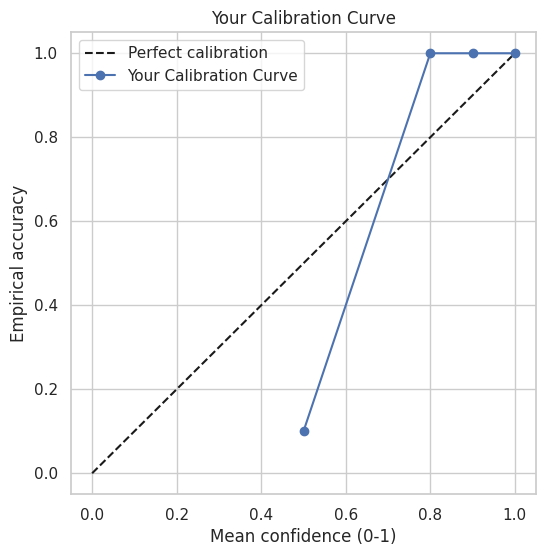

Saved self results to assignment_outputs/


In [2]:
# Part B: Measure YOUR calibration
# IMPORTANT: Fill this honestly before running model cells.

from IPython.display import display

RESULT_PATH = f"{OUTPUT_FOLDER_1}/self_results_scored.csv"

if "df_questions" not in globals():
    df_questions = pd.read_csv(f"{OUTPUT_FOLDER_1}/questions.csv")

# Sample 5 questions from each difficulty for self-evaluation (20 total)
rng_seed = 42
self_sample = (
    df_questions.groupby("difficulty", group_keys=False)
    .sample(n=5, random_state=rng_seed)
    .reset_index(drop=True)
)

# Create a template you should fill manually
self_answers_path = Path(f"{OUTPUT_FOLDER_1}/self_answers.csv")
if self_answers_path.exists():
    self_df = pd.read_csv(self_answers_path)
else:
    self_df = self_sample[["question", "difficulty"]].copy()
    self_df["my_answer"] = ""
    self_df["my_confidence"] = np.nan  # 50 to 100
    self_df.to_csv(self_answers_path, index=False)

print("Fill your answers in:", self_answers_path)
display(self_df.head(10))

# Re-load in case you edited the CSV externally
self_df = pd.read_csv(self_answers_path)

# Backfill legacy templates that may be missing difficulty
if "difficulty" not in self_df.columns:
    self_df = self_df.merge(
        self_sample[["question", "difficulty"]],
        on="question",
        how="left",
    )
    self_df.to_csv(self_answers_path, index=False)

self_df = self_df.merge(
    df_questions[["question", "answer"]],
    on="question",
    how="left",
)

required_cols = {"question", "difficulty", "my_answer", "my_confidence"}
missing = required_cols - set(self_df.columns)
if missing:
    raise ValueError(f"Missing columns in self_answers.csv: {missing}")

# Compute metrics only when data is complete
if self_df["my_answer"].astype(str).str.strip().eq("").any() or self_df["my_confidence"].isna().any():
    print("Please complete all my_answer and my_confidence values (50-100) in self_answers.csv, then re-run this cell.")
else:
    self_df["my_confidence"] = self_df["my_confidence"].astype(float).clip(50, 100)
    self_scored_path = Path(RESULT_PATH)
    if not self_scored_path.exists():      
        print("Evaluating correctness of your answers...")
        self_df[["correct", "reason"]] = self_df.apply(
            lambda r: is_correct_answer(r["question"], r["my_answer"], r["answer"]), axis=1, result_type="expand"
        )
    else:
        print(f"Loading previously scored results from {RESULT_PATH}...")
        self_df = pd.read_csv(RESULT_PATH)


    summary = (
        self_df.groupby("difficulty", as_index=False)
        .agg(
            accuracy=("correct", "mean"),
            avg_confidence=("my_confidence", "mean"),
            n=("question", "size"),
        )
    )
    summary["calibration_error_abs"] = (summary["avg_confidence"] / 100.0 - summary["accuracy"]).abs()
    overall_cal_error = summary["calibration_error_abs"].mean()

    display(summary)
    print(f"Overall calibration error (mean abs |conf-acc| across categories): {overall_cal_error:.3f}")

    plot_calibration_curve(
        self_df.rename(columns={"my_confidence": "confidence"}),
        title="Your Calibration Curve",
        conf_col="confidence",
        correct_col="correct",
    )

    self_df.to_csv(RESULT_PATH, index=False)
    summary.to_csv(f"{OUTPUT_FOLDER_1}/self_summary.csv", index=False)
    print("Saved self results to assignment_outputs/")

### Part C: Measure the MODEL's Calibration (15 points)

Query an LLM (use the OpenAI API, Anthropic API, or any accessible API — free tiers are fine) with all 50 questions. For each question, use the following prompt template:

```
Answer the following question. After your answer, rate your confidence
from 0% to 100% that your answer is correct. Format your response as:
Answer: [your answer]
Confidence: [X]%
```

Then:
1. **Parse** the model's answers and confidence ratings
2. **Score** each answer as correct or incorrect (you may need fuzzy matching — document your approach)
3. Compute the **model's calibration** the same way you computed yours:
   - Accuracy per difficulty category
   - Average confidence per difficulty category
   - Calibration error per category
   - Calibration plot

4. **Compare** your calibration plot to the model's calibration plot side by side.

**Key analysis questions** (answer in a markdown cell):
- Is the model overconfident, underconfident, or well-calibrated?
- Does its calibration error vary with difficulty? (Compare to humans from Lichtenstein et al. 1982)
- How does the model handle the unanswerable questions? Does it say "I don't know" or does it confabulate confidently?
- How does the model's calibration pattern differ from yours?

Loaded cached baseline outputs: part1_outputs/model_baseline_outputs.csv
Loaded cached scored baseline outputs: part1_outputs/model_baseline_scored.csv
Model summary by difficulty


,difficulty,accuracy,avg_confidence,n,calibration_error_abs
0,easy,1.0,100.000000,10,0.000000
1,hard,1.0,99.666667,15,0.003333
2,medium,1.0,100.000000,15,0.000000
3,unanswerable,0.9,100.000000,10,0.100000


Model ECE: 0.019000000000000128


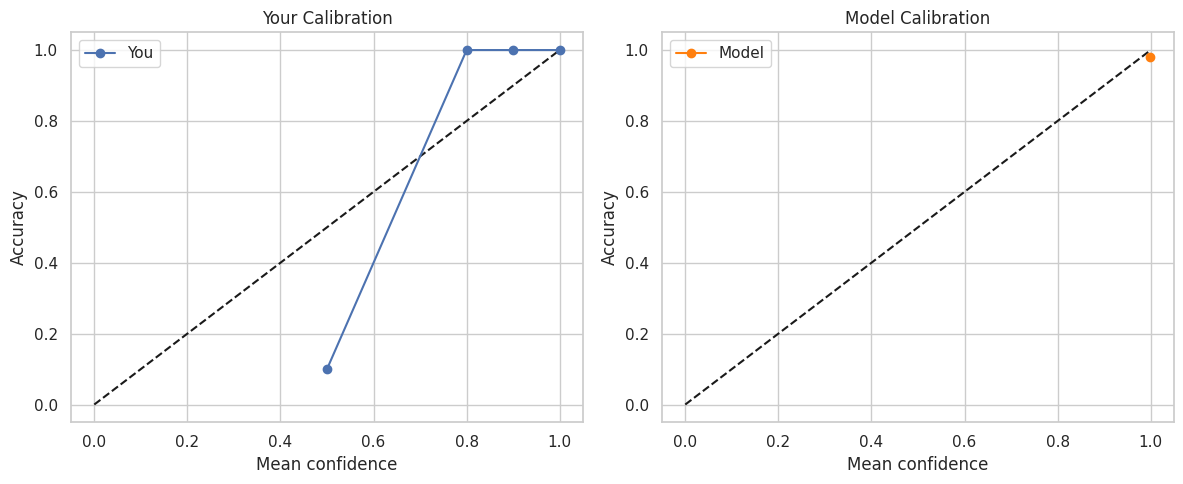

Saved model baseline scored outputs to assignment_outputs/


In [3]:
# Part C: Measure MODEL calibration (baseline)
# OpenRouter setup: uses OpenAI-compatible client with OpenRouter base URL.

import os

if "df_questions" not in globals():
    df_questions = pd.read_csv(f"{OUTPUT_FOLDER_1}/questions.csv")

BASE_PROMPT = (
    "Answer the following question. After your answer, rate your confidence\n"
    "from 0% to 100% that your answer is correct. Format your response as:\n"
    "Answer: [your answer]\n"
    "Confidence: [X]%"
)


def parse_answer_confidence(text: str):
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return "", np.nan

    text = str(text)
    answer_match = re.search(r"Answer\s*:\s*(.+?)(?:\n|$)", text, flags=re.IGNORECASE | re.DOTALL)
    conf_match = re.search(r"Confidence\s*:\s*([0-9]{1,3})(?:\s*%)?", text, flags=re.IGNORECASE)

    answer = answer_match.group(1).strip() if answer_match else text.strip().split("\n")[0]
    if conf_match:
        confidence = float(conf_match.group(1))
    else:
        confidence = np.nan
    confidence = np.clip(confidence, 0, 100) if not np.isnan(confidence) else np.nan
    return answer, confidence


def get_openrouter_client():
    from openai import OpenAI

    return OpenAI(
        api_key=API_TOKEN,
        base_url=API_BASE_URL,
    )


def query_openrouter_for_questions(df, model=DEFAULT_MODEL, temperature=0.2, system_prompt="You are a concise factual assistant."):
    rows = []

    for i, row in df.iterrows():
        user_msg = f"{BASE_PROMPT}\n\nQuestion: {row['question']}"
        try:
            raw = call_ai_raw(
                system_prompt=system_prompt,
                user_message=user_msg,
                model=model,
                temperature=temperature,
            )
        except Exception as e:
            print(f"Error querying OpenRouter for question {i + 1}: {e}")
            raw = ""
            return pd.DataFrame(rows)

        ans, conf = parse_answer_confidence(raw)
        rows.append(
            {
                "question": row["question"],
                "ground_truth": row["answer"],
                "difficulty": row["difficulty"],
                "raw_response": raw,
                "model_answer": ans,
                "confidence": conf,
                "model": model,
                "temperature": temperature,
            }
        )
        if (i + 1) % 10 == 0:
            print(f"Completed {i + 1}/{len(df)}")

    return pd.DataFrame(rows)


baseline_path = Path(f"{OUTPUT_FOLDER_1}/model_baseline_outputs.csv")

if baseline_path.exists():
    model_df = pd.read_csv(baseline_path)
    print("Loaded cached baseline outputs:", baseline_path)
else:
    model_df = query_openrouter_for_questions(df_questions, model=DEFAULT_MODEL, temperature=0.2)
    model_df.to_csv(baseline_path, index=False)
    print("Saved baseline outputs:", baseline_path)

score_path = Path(f"{OUTPUT_FOLDER_1}/model_baseline_scored.csv")

if score_path.exists():
    model_df = pd.read_csv(score_path)
    print("Loaded cached scored baseline outputs:", score_path)
else:
    model_df[["correct", "reason"]] = model_df.apply(
        lambda r: is_correct_answer(r["question"], r["model_answer"], r["ground_truth"]), axis=1, result_type="expand"
    )

model_summary = (
    model_df.groupby("difficulty", as_index=False)
    .agg(
        accuracy=("correct", "mean"),
        avg_confidence=("confidence", "mean"),
        n=("question", "size"),
    )
)
model_summary["calibration_error_abs"] = (model_summary["avg_confidence"] / 100.0 - model_summary["accuracy"]).abs()

print("Model summary by difficulty")
display(model_summary)
print("Model ECE:", expected_calibration_error(model_df, conf_col="confidence", correct_col="correct", n_bins=10))

self_path = Path(f"{OUTPUT_FOLDER_1}/self_results_scored.csv")
if self_path.exists():
    self_scored = pd.read_csv(self_path)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    bucket_self = calibration_by_bucket(
        self_scored.rename(columns={"my_confidence": "confidence"}),
        conf_col="confidence",
        correct_col="correct",
        n_bins=10,
    )
    plt.plot([0, 1], [0, 1], "k--")
    if not bucket_self.empty:
        plt.plot(bucket_self["avg_confidence"], bucket_self["accuracy"], marker="o", label="You")
    plt.title("Your Calibration")
    plt.xlabel("Mean confidence")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    bucket_model = calibration_by_bucket(model_df, conf_col="confidence", correct_col="correct", n_bins=10)
    plt.plot([0, 1], [0, 1], "k--")
    if not bucket_model.empty:
        plt.plot(bucket_model["avg_confidence"], bucket_model["accuracy"], marker="o", label="Model", color="tab:orange")
    plt.title("Model Calibration")
    plt.xlabel("Mean confidence")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Self-scored file not found; skipping side-by-side plot.")

model_df.to_csv(f"{OUTPUT_FOLDER_1}/model_baseline_scored.csv", index=False)
model_summary.to_csv(f"{OUTPUT_FOLDER_1}/model_baseline_summary.csv", index=False)
print("Saved model baseline scored outputs to assignment_outputs/")

### Analysis responses
- Is the model overconfident, underconfident, or well-calibrated?
- Does its calibration error vary with difficulty? (Compare to humans from Lichtenstein et al. 1982)
- How does the model handle the unanswerable questions? Does it say "I don't know" or does it confabulate confidently?
- How does the model's calibration pattern differ from yours?

    Brief overview of my code: i use basic pattern matching to validate if the model's response in correct, then fallback to llm checking if there is no pattern matching. Surprisingly (or not), the AI model got everything correct, and justified unanswerable questions properly, rather than just giving it a straight answer. This has resulted in 100% confidence almost all the time and correct answer all the time, making the graph just one dot that sits on the well-calibrated line. The differnce in pattern i guess, is just that the AI model is way better than me.

In [4]:
# utility cell to validate if wrong answers are actually wrong
csv_to_inspect = "model_baseline_scored.csv"
df_scores = pd.read_csv(f"{OUTPUT_FOLDER_1}/{csv_to_inspect}")

for row in df_scores.itertuples():
    if row.correct == 1: 
        continue
    q = row.question
    model_ans = row.model_answer 
    model_conf = row.confidence
    ground_truth = row.ground_truth
    why_wrong = row.reason
    print(f"Q: {q}\nModel Answer: {model_ans}\nConfidence: {model_conf}%\nGround Truth: {ground_truth}\nWhy Wrong: {why_wrong}\n{'-'*50}")

Q: Which came first in all possible universes, the chicken or the egg?
Model Answer: The egg. Evolutionarily, amniotic eggs existed in reptiles and ancestral species long before the specific species *Gallus gallus domesticus* (the chicken) evolved.
Confidence: 100.0%
Ground Truth: unanswerable
Why Wrong: The model provided a definitive answer based on evolutionary biology instead of justifying why the question is unanswerable in the context of 'all possible universes'.
--------------------------------------------------


### Part D: Can You Improve the Model's Calibration? (10 points)

Try at least **two** prompt engineering interventions to improve the model's calibration. Ideas:
- Ask it to "think step by step before rating confidence"
- Ask it to "list reasons it might be wrong before answering"
- Ask it to "rate confidence on a scale of 1-10 instead of percentage"
- Provide a few-shot example of well-calibrated answers (including "I'm not sure")
- Ask in a different persona ("You are a careful scientist who hates being wrong...")

For each intervention:
1. Re-run the 50 questions with the new prompt
2. Compute calibration again
3. Compare to the baseline

**Report**: Which intervention helped most? Which didn't help? Why do you think that is (connect to what you know about RLHF and reward signals from Lecture 3)?

Loaded cached intervention run: baseline
Loaded cached scored intervention run: baseline
Loaded cached intervention run: reason_before_confidence
Saved scored intervention run: part1_outputs/model_reason_before_confidence_scored.csv
Completed 10/50
Completed 20/50
Completed 30/50
Completed 40/50
Completed 50/50
Saved intervention run: part1_outputs/model_list_why_wrong_outputs.csv
Saved scored intervention run: part1_outputs/model_list_why_wrong_scored.csv
Intervention summary by difficulty


,intervention,difficulty,accuracy,avg_confidence,n,calibration_error_abs
0,list_why_wrong,easy,1.000000,100.000000,10,0.000000
1,list_why_wrong,hard,1.000000,99.733333,15,0.002667
2,list_why_wrong,medium,1.000000,100.000000,15,0.000000
3,list_why_wrong,unanswerable,0.800000,100.000000,10,0.200000
4,reason_before_confidence,easy,1.000000,100.000000,10,0.000000
5,reason_before_confidence,hard,0.933333,99.666667,15,0.063333
6,reason_before_confidence,medium,1.000000,100.000000,15,0.000000
7,reason_before_confidence,unanswerable,0.900000,100.000000,10,0.100000


Overall intervention performance


,intervention,ece,accuracy,avg_confidence
1,reason_before_confidence,0.0390,0.96,99.90
0,list_why_wrong,0.0392,0.96,99.92


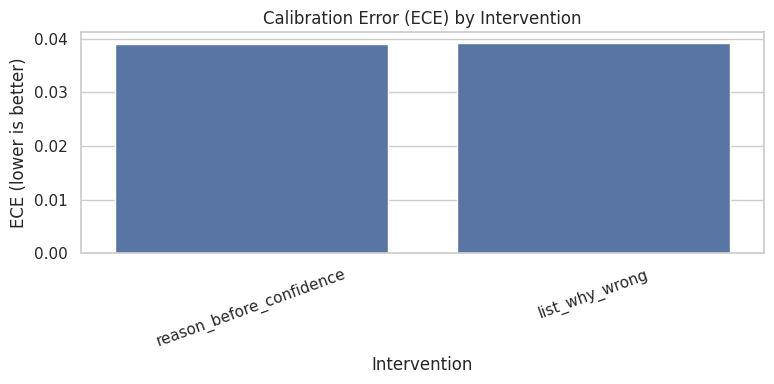

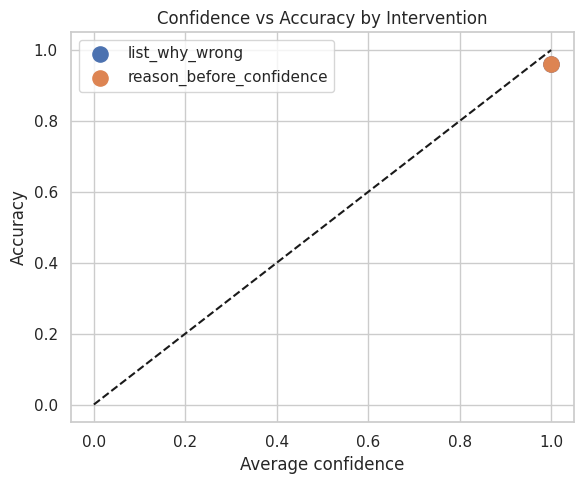

Saved intervention summaries to assignment_outputs/


In [5]:
# Part D: Prompt engineering interventions for calibration

import os

if "df_questions" not in globals():
    df_questions = pd.read_csv(f"{OUTPUT_FOLDER_1}/questions.csv")

if "query_openrouter_for_questions" not in globals():
    raise RuntimeError("Run Part C cell first to define OpenRouter query helpers.")

interventions = {
    "baseline": "You are a concise factual assistant.",
    "reason_before_confidence": (
        "You are a careful assistant. Think through the evidence briefly before answering. "
        "Then provide confidence conservatively."
    ),
    "list_why_wrong": (
        "You are a careful scientist who hates being wrong. Before final confidence, "
        "consider at least two reasons your answer might be wrong."
    ),
}

all_runs = []
for name, sys_prompt in interventions.items():
    run_path = Path(f"{OUTPUT_FOLDER_1}/model_{name}_outputs.csv")
    start_from = 0
    if run_path.exists():
        run_df = pd.read_csv(run_path)
        print(f"Loaded cached intervention run: {name}")
        start_from = len(run_df)
        if len(run_df) != len(df_questions):
            print(f"Intervention run {name} is incomplete, continuing from question {len(run_df) + 1}")
    else:
        run_df = query_openrouter_for_questions(
            df_questions.iloc[start_from:],
            model=DEFAULT_MODEL,
            temperature=0.2,
            system_prompt=sys_prompt,
        )

        run_df.to_csv(run_path, index=False)
        print(f"Saved intervention run: {run_path}")

    correct_path = Path(f"{OUTPUT_FOLDER_1}/model_{name}_scored.csv")
    if correct_path.exists():
        run_df = pd.read_csv(correct_path)
        print(f"Loaded cached scored intervention run: {name}")
    else:
        run_df["intervention"] = name
        run_df[["correct", "reason"]] = run_df.apply(
            lambda r: is_correct_answer(r["question"], r["model_answer"], r["ground_truth"]), axis=1, result_type="expand"
        )
        if len(run_df) != 0:
            run_df.to_csv(correct_path, index=False)
            print(f"Saved scored intervention run: {correct_path}")
    all_runs.append(run_df)

if not all_runs:
    raise RuntimeError("No intervention runs available. Provide OPENROUTER_API_KEY or cached CSV files.")

intervention_df = pd.concat(all_runs, ignore_index=True)
intervention_df.to_csv(f"{OUTPUT_FOLDER_1}/interventions_all_scored.csv", index=False)

summary = (
    intervention_df.groupby(["intervention", "difficulty"], as_index=False)
    .agg(
        accuracy=("correct", "mean"),
        avg_confidence=("confidence", "mean"),
        n=("question", "size"),
    )
)
summary["calibration_error_abs"] = (summary["avg_confidence"] / 100.0 - summary["accuracy"]).abs()

overall = (
    intervention_df.groupby("intervention", as_index=False)
    .apply(lambda g: pd.Series({
        "ece": expected_calibration_error(g, conf_col="confidence", correct_col="correct", n_bins=10),
        "accuracy": g["correct"].mean(),
        "avg_confidence": g["confidence"].mean(),
    }), include_groups=False)
    .reset_index(drop=True)
)

print("Intervention summary by difficulty")
display(summary)
print("Overall intervention performance")
display(overall.sort_values("ece"))

plt.figure(figsize=(8, 4))
sns.barplot(data=overall.sort_values("ece"), x="intervention", y="ece")
plt.title("Calibration Error (ECE) by Intervention")
plt.ylabel("ECE (lower is better)")
plt.xlabel("Intervention")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
for _, row in overall.iterrows():
    plt.scatter(row["avg_confidence"] / 100.0, row["accuracy"], s=120, label=row["intervention"])
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Average confidence")
plt.ylabel("Accuracy")
plt.title("Confidence vs Accuracy by Intervention")
plt.legend()
plt.tight_layout()
plt.show()

summary.to_csv(f"{OUTPUT_FOLDER_1}/interventions_summary_by_difficulty.csv", index=False)
overall.to_csv(f"{OUTPUT_FOLDER_1}/interventions_overall.csv", index=False)
print("Saved intervention summaries to assignment_outputs/")

### Bonus: Token-Level Probabilities (10 bonus points)

If you're using an API that exposes log-probabilities (e.g., OpenAI with `logprobs=True`):
1. Extract the **token-level probabilities** for the model's answers
2. Compare the model's **stated** confidence (from the text) to its **actual** token probabilities
3. Are they correlated? Is the model's internal uncertainty (log-probs) better calibrated than its stated confidence?

This gets at a deep question from Lecture 2 (Representation): the model may have an internal representation of uncertainty that differs from what it expresses in text. The expressed confidence was shaped by RLHF; the log-probs were shaped by pre-training.

In [6]:
# Bonus: Token-level probabilities vs stated confidence

import os

if "df_questions" not in globals():
    df_questions = pd.read_csv(f"{OUTPUT_FOLDER_1}/questions.csv")

if "get_openrouter_client" not in globals():
    raise RuntimeError("Run Part C first to initialize OpenRouter helpers.")


def query_with_logprobs(df, model="glm-5.1:cloud", temperature=0.2):
    client = get_openrouter_client()
    rows = []

    for i, row in df.iterrows():
        user_msg = f"{BASE_PROMPT}\n\nQuestion: {row['question']}"
        resp = client.chat.completions.create(
            model=model,
            temperature=temperature,
            logprobs=True,
            top_logprobs=5,
            messages=[
                {"role": "system", "content": "You are a concise factual assistant."},
                {"role": "user", "content": user_msg},
            ],
        )

        print(f"Raw response for question {i + 1}:", resp)

        raw = resp.choices[0].message.content
        if raw is not None:
            ans, conf = parse_answer_confidence(raw)

        token_logprobs = []
        if getattr(resp.choices[0], "logprobs", None) and getattr(resp.choices[0].logprobs, "content", None):
            try:
                content = resp.choices[0].logprobs.content # type: ignore (guarded with if clause)
                token_logprobs = [t.logprob for t in content if t.logprob is not None] # type: ignore
            except Exception:
                token_logprobs = []


        print(f"MEAN TOKEN PROB: {token_logprobs} for answer: {ans} with stated confidence: {conf}%")

        mean_token_prob = float(np.exp(np.mean(token_logprobs))) if token_logprobs else np.nan

        rows.append(
            {
                "question": row["question"],
                "ground_truth": row["answer"],
                "difficulty": row["difficulty"],
                "raw_response": raw,
                "model_answer": ans,
                "stated_confidence": conf,
                "mean_token_prob": mean_token_prob,
            }
        )

        if (i + 1) % 10 == 0:
            print(f"Completed {i + 1}/{len(df)}")

    return pd.DataFrame(rows)


bonus_path = Path(f"{OUTPUT_FOLDER_1}/model_logprobs_outputs.csv")

if bonus_path.exists():
    bonus_df = pd.read_csv(bonus_path)
    print("Loaded cached logprobs output")
else:
    print("Querying model with logprobs for bonus analysis...")
    bonus_df = query_with_logprobs(df_questions)
    bonus_df.to_csv(bonus_path, index=False)

    bonus_df[["correct", "reason"]] = bonus_df.apply(
        lambda r: is_correct_answer(r["question"], r["model_answer"], r["ground_truth"]), axis=1, result_type="expand"
    )

bonus_df = bonus_df.dropna(subset=["stated_confidence", "mean_token_prob"]).copy()

if bonus_df.empty:
    print("No valid rows with both stated confidence and token probabilities.")
else:
    corr = bonus_df["stated_confidence"].corr(bonus_df["mean_token_prob"])
    print(f"Correlation between stated confidence and mean token probability: {corr:.3f}")

    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=bonus_df, x="stated_confidence", y="mean_token_prob", hue="correct")
    plt.title("Stated Confidence vs Mean Token Probability")
    plt.xlabel("Stated confidence (%)")
    plt.ylabel("Mean token probability (exp(mean logprob))")
    plt.tight_layout()
    plt.show()

    by_correct = bonus_df.groupby("correct", as_index=False).agg(
        mean_stated_confidence=("stated_confidence", "mean"),
        mean_token_prob=("mean_token_prob", "mean"),
        n=("question", "size"),
    )
    display(by_correct)

bonus_df.to_csv(f"{OUTPUT_FOLDER_1}/model_logprobs_scored.csv", index=False)
print("Saved bonus analysis outputs.")

Querying model with logprobs for bonus analysis...
Raw response for question 1: ChatCompletion(id='chatcmpl-674', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Answer: Paris\nConfidence: 100%', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning='1.  **Analyze the Request:**\n    *   Question: "What is the capital of France?"\n    *   Constraint 1: Be a concise factual assistant.\n    *   Constraint 2: Format the response exactly as:\n        Answer: [your answer]\n        Confidence: [X]%\n\n2.  **Determine the Answer:**\n    *   The capital of France is Paris.\n\n3.  **Determine the Confidence:**\n    *   This is a widely known, objective geographical fact. Confidence is 100%.\n\n4.  **Format the Output:**\n    *   Answer: Paris\n    *   Confidence: 100%'))], created=1776135062, model='glm-5.1:cloud', object='chat.completion', service_tier=None, system_fingerprint='fp_ollam

KeyboardInterrupt: 

### 🪞 Metacognitive Reflection — Problem 1 (graded, 5 points included above)

Write 200–400 words answering these questions. **This must be in your own voice — not generated by an LLM.**

1. Were you surprised by your own calibration results? Where were you most overconfident?
2. Were you surprised by the model's calibration? How did it compare to your expectations?
3. What did you learn about the relationship between confidence and accuracy — in yourself and in the model?
4. How did you use LLMs during this problem? What did you prompt for, what did you have to fix, and what did the LLM get wrong?
5. Connect your findings to one concept from the course (e.g., Goodhart's Law, prediction error, the Bayesian brain). How does your data illustrate or challenge that concept?

*Your reflection here (double-click to edit):*

I was actually surprised by how little general knowledge I have (lol) and I am completely loss most of the time. I guess this is a consequences of being too invested in CS and all the domain specific knowledge that I forgot there's a world outside. Inherently, i was not super confident of all of my responses and the output shows it. For the model's calibration, I think the intended outcome wan't achieved here as the models has gotten so smart today (i used qwen3.6-plus), that it answered everything correctly with 100% confidence (most of the time), which is kinda well callibrated in a sense. In an attempt to give this experiment a better chance of showing the intended output, I have repeated the experiment with gemma4:31b, a smaller model recently released by Google. While I could have chose some tiny and stupid model from a while ago, I thought this would give a fairer representation on what a LLM can do given limited compute resources, which is a reasonable constraint vs. just using an inferior model of the same or larger size. However to my horror, even this model got all but one question correct, with the one being marked wrong very contestable.

The relationship between confidence and accuracy: In myself, I guess I hate to be confidently wrong, that's why i tend to indicate the confidence as significantly lower than my actual confidence. However, in the machine's case, it almost always indicate 100% confidence, which might signal overconfidence, yet the model also get the answer right (almost) all the time. Therefore it is hard to judge if the relationship between confidence and accuracy would scale well, with more questions of different variety.


---
## Problem 2: Temperature, Creativity, and Mode Collapse — Does Optimization Kill Novelty?
### (35 points + 10 bonus)

**Course connections**: Creativity (mode collapse, exploration vs exploitation), Learning & Reward (RLHF as reward shaping), Representation (traversal of embedding space), Decisions (temperature as the creativity dial).

**The question**: In Lecture 5 (Creativity), we argued that RLHF causes mode collapse — the model converges on safe, crowd-pleasing outputs and loses the tail distribution where novelty lives. In this problem, you'll measure this directly.

---

### Part A: The Divergent Thinking Experiment (10 points)

Use the **Alternative Uses Task** (Guilford, 1967) — the same test you did in the Creativity lecture.

Pick **3 common objects** (e.g., brick, paperclip, shoe). For each object, prompt the LLM to:
> "List 20 unusual uses for a [object]. Be creative and surprising."

Run this at **5 different temperature settings**: 0.0, 0.3, 0.7, 1.0, 1.5 (or as close as the API allows).

For each (object × temperature) combination, record all 20 responses.

That gives you 3 objects × 5 temperatures × 20 uses = 300 data points.

In [1]:
# Problem 2, Part A: Divergent thinking across temperatures

import os
from pathlib import Path
from IPython.display import display
import pandas as pd
import numpy as np
import re
import time

API_BASE_URL = os.environ.get("API_BASE_URL", "https://openrouter.ai/api/v1")
DEFAULT_MODEL = os.environ.get("DEFAULT_MODEL", "qwen/qwen3.6-plus:free")
API_TOKEN = os.environ.get("API_KEY", None)
if API_TOKEN is None:
    raise RuntimeError("Please set the API_KEY environment variable to your OpenRouter API token.")
else:
    print(f"Using {API_BASE_URL} with model {DEFAULT_MODEL}")

OUTPUT_FOLDER_2 = Path("part2_outputs")
if not OUTPUT_FOLDER_2.exists():
    print(f"Creating output folder at {OUTPUT_FOLDER_2}")
    OUTPUT_FOLDER_2.mkdir()

objects = ["brick", "paperclip", "shoe"]
temperatures = [0.0, 0.3, 0.7, 1.0, 1.5]
count = 20

PROMPT_TEMPLATE = "List {count} unusual uses for a {obj}. Be creative and surprising. Return as a numbered list."

def parse_numbered_list(text: str):
    lines = [l.strip() for l in str(text).splitlines() if l.strip()]
    uses = []
    for line in lines:
        line = re.sub(r"^\d+[\).:-]?\s*", "", line)
        if line:
            uses.append(line)
    return uses[:count]

def get_openrouter_client_local():
    from openai import OpenAI

    return OpenAI(api_key=API_TOKEN, base_url=API_BASE_URL)

def call_ai_raw(system_prompt: str, user_message: str, model=None, temperature: float = 0.2) -> str:
    from openai import OpenAI

    base_url = API_BASE_URL
    chosen_model = model or DEFAULT_MODEL

    client = OpenAI(api_key=API_TOKEN, base_url=base_url)
    attempt = 0
    while attempt < 3:
        try:
            resp = client.chat.completions.create(
                model=chosen_model,
                temperature=float(temperature),
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_message},
                ],
            )
        except Exception as e:
            if attempt < 2:
                print("Error calling OpenRouter:", e)
                print("Retrying in " + str(2 ** attempt) + " seconds...")
                time.sleep(2 ** attempt)
                attempt += 1
            else:
                print("Error calling OpenRouter:", e)
                print("Aborting after 3 attempts.")
                raise e
        if resp is not None:
            break

    if getattr(resp, "choices", None):
        first_choice = resp.choices[0] # type: ignore
        message = getattr(first_choice, "message", None)
        return getattr(message, "content", "") or ""
    return ""

def run_divergent_experiment(objects, temperatures, model=DEFAULT_MODEL):
    rows = []

    for obj in objects:
        for temp in temperatures:
            prompt = PROMPT_TEMPLATE.format(obj=obj, count=count)

            raw = call_ai_raw(
                system_prompt="You are a creative but concise assistant.",
                user_message=prompt,
                model=model,
                temperature=temp,
            )

            uses = parse_numbered_list(raw)
            for i in range(count):
                use_text = uses[i] if i < len(uses) else ""
                rows.append(
                    {
                        "object": obj,
                        "temperature": temp,
                        "item_index": i + 1,
                        "use_text": use_text,
                    }
                )
            print(f"Done object={obj}, temp={temp}")

    return pd.DataFrame(rows)


out_path = Path(f"{OUTPUT_FOLDER_2}/divergent_uses.csv")
if out_path.exists():
    divergent_df = pd.read_csv(out_path)
    print("Loaded cached divergent uses:", out_path)
else:
    divergent_df = run_divergent_experiment(objects, temperatures)
    divergent_df.to_csv(out_path, index=False)
    print("Saved:", out_path)

print("Rows:", len(divergent_df))
display(divergent_df.head(12))
print("Expected 300 rows for complete data (3 objects x 5 temps x 20 uses).")

Using https://ollama.com/v1/ with model gemma4:31b-cloud
Loaded cached divergent uses: part2_outputs/divergent_uses.csv
Rows: 300


,object,temperature,item_index,use_text
0,brick,0.0,1,**Nutcracker:** A heavy-duty tool for stubborn...
1,brick,0.0,2,**DIY Bookend:** Wrap it in velvet or leather ...
2,brick,0.0,3,**Incense Holder:** Drill a small hole in the ...
3,brick,0.0,4,**Pasta Press:** Place it (wrapped in foil) at...
4,brick,0.0,5,**Aquarium Decor:** A weathered brick creates ...
5,brick,0.0,6,"**Doorstop:** The classic, low-tech solution f..."
6,brick,0.0,7,**Boot Scraper:** Use the rough texture to cle...
7,brick,0.0,8,**Paperweight:** For those extremely windy out...
8,brick,0.0,9,**Improvised Dumbbell:** A makeshift weight fo...
9,brick,0.0,10,**Garden Edge:** Use them as a rustic border f...


Expected 300 rows for complete data (3 objects x 5 temps x 20 uses).


### Part B: Measuring Creativity — Design Your Own Rubric (10 points)

This is the hard part. There is no standard metric for creativity (that was the Evaluation Problem from Lecture 5). You need to **design a scoring rubric** with at least 3 dimensions. Suggested dimensions (pick 3-4, or invent your own):

- **Originality**: How surprising/uncommon is the use? (1 = obvious, 5 = never heard of it)
- **Feasibility**: Could you actually do this? (1 = impossible, 5 = easy)
- **Humour**: Is it funny or playful? (1 = not at all, 5 = genuinely funny)
- **Elaboration**: How detailed/specific is the response? (1 = generic, 5 = vivid)
- **Category diversity**: Does the list span different domains (physical, social, artistic, absurd)?

**Important**: Score a random sample of **5 uses per temperature** per object (75 total). Do this yourself — do NOT use an LLM to evaluate creativity.

Then compute and plot:
1. **Average score per dimension** as a function of temperature
2. **Lexical diversity** (number of unique words / total words) as a function of temperature
3. **Semantic diversity** (average pairwise cosine distance between sentence embeddings) as a function of temperature

For semantic diversity, use a sentence embedding model (e.g., `sentence-transformers/all-MiniLM-L6-v2` from HuggingFace).

Sample rows for rubric scoring:


,object,temperature,level_2,item_index,use_text
0,brick,0.0,14,15,**Bird Bath Base:** Stack them to elevate a sh...
1,brick,0.0,5,6,"**Doorstop:** The classic, low-tech solution f..."
2,brick,0.0,4,5,**Aquarium Decor:** A weathered brick creates ...
3,brick,0.0,17,18,**Rustic Step:** A temporary boost to reach a ...
4,brick,0.0,8,9,**Improvised Dumbbell:** A makeshift weight fo...
...,...,...,...,...,...
70,shoe,1.5,294,15,**Poundcake Mold:** Greasing a sturdy boot for...
71,shoe,1.5,285,6,**Wildlife Camera Hide:** A large rain boot ca...
72,shoe,1.5,284,5,**Ice Pack Holder:** Slide a gel pack into a s...
73,shoe,1.5,297,18,"**Cat Toy:** An old sneaker is the ultimate ""c..."


Fill rubric scores (1-5) in: part2_outputs/creativity_rubric_scores.csv


,object,temperature,item_index,use_text,originality,feasibility,humour,elaboration
0,brick,0.0,15,**Bird Bath Base:** Stack them to elevate a sh...,NaN,NaN,NaN,NaN
1,brick,0.0,6,"**Doorstop:** The classic, low-tech solution f...",NaN,NaN,NaN,NaN
2,brick,0.0,5,**Aquarium Decor:** A weathered brick creates ...,NaN,NaN,NaN,NaN
3,brick,0.0,18,**Rustic Step:** A temporary boost to reach a ...,NaN,NaN,NaN,NaN
4,brick,0.0,9,**Improvised Dumbbell:** A makeshift weight fo...,NaN,NaN,NaN,NaN
5,brick,0.3,15,**DIY Bench Base:** Stack them with wooden pla...,NaN,NaN,NaN,NaN
6,brick,0.3,6,**Aquarium Decor:** Create a rustic cave for b...,NaN,NaN,NaN,NaN
7,brick,0.3,5,**Paint Palette:** Use the porous surface to m...,NaN,NaN,NaN,NaN
8,brick,0.3,18,**Door Wedge:** Shave a side at an angle to ja...,NaN,NaN,NaN,NaN
9,brick,0.3,9,**Boot Scraper:** Place it by the door to scra...,NaN,NaN,NaN,NaN


Please fill all rubric values (1-5), then re-run this cell.


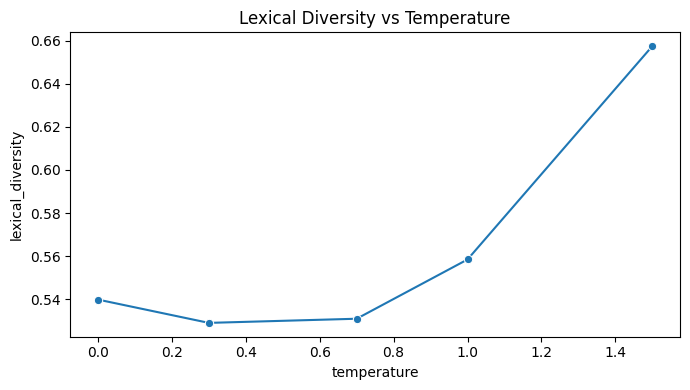

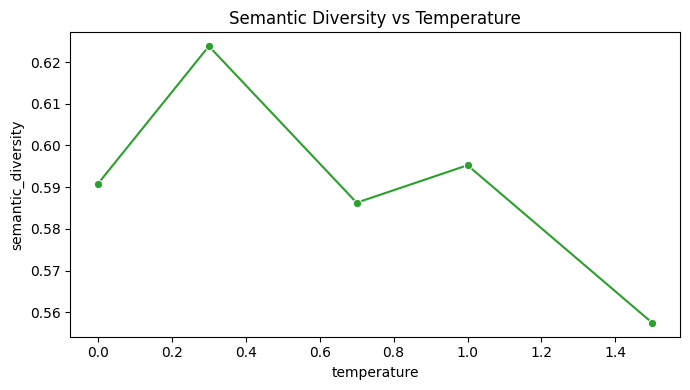

,temperature,lexical_diversity
0,0.0,0.539936
1,0.3,0.529141
2,0.7,0.531065
3,1.0,0.558533
4,1.5,0.657391


,temperature,semantic_diversity
0,0.0,0.590829
1,0.3,0.623819
2,0.7,0.586266
3,1.0,0.595257
4,1.5,0.557435


Saved creativity metrics to assignment_outputs/


In [3]:
# Problem 2, Part B: Creativity rubric + diversity metrics

from collections import Counter
from itertools import combinations
import json
from urllib import request, error
import matplotlib.pyplot as plt
import seaborn as sns

BASE_URL_LOCAL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434").rstrip("/")
EMBED_MODEL = os.environ.get("OLLAMA_EMBED_MODEL", "nomic-embed-text")

if "divergent_df" not in globals():
    divergent_df = pd.read_csv(f"{OUTPUT_FOLDER_2}/divergent_uses.csv")

# 1) Manual rubric scoring template (5 uses per temperature per object => 75 rows)
rubric_path = Path(f"{OUTPUT_FOLDER_2}/creativity_rubric_scores.csv")

sample_df = (
    divergent_df.groupby(["object", "temperature"], group_keys=True)
    .apply(lambda x: x.sample(5, random_state=123))
    .reset_index()
)

print("Sample rows for rubric scoring:")
display(sample_df)

if rubric_path.exists():
    rubric_df = pd.read_csv(rubric_path)
else:
    rubric_df = sample_df[["object", "temperature", "item_index", "use_text"]].copy()
    rubric_df["originality"] = np.nan
    rubric_df["feasibility"] = np.nan
    rubric_df["humour"] = np.nan
    rubric_df["elaboration"] = np.nan
    rubric_df.to_csv(rubric_path, index=False)

print("Fill rubric scores (1-5) in:", rubric_path)
display(rubric_df.head(10))

rubric_df = pd.read_csv(rubric_path)
if rubric_df[["originality", "feasibility", "humour", "elaboration"]].isna().any().any():
    print("Please fill all rubric values (1-5), then re-run this cell.")
else:
    rubric_long = rubric_df.melt(
        id_vars=["object", "temperature", "item_index", "use_text"],
        value_vars=["originality", "feasibility", "humour", "elaboration"],
        var_name="dimension",
        value_name="score",
    )

    rubric_summary = (
        rubric_long.groupby(["temperature", "dimension"], as_index=False)
        .agg(avg_score=("score", "mean"), n=("score", "size"))
    )

    plt.figure(figsize=(9, 5))
    sns.lineplot(data=rubric_summary, x="temperature", y="avg_score", hue="dimension", marker="o")
    plt.title("Average Creativity Rubric Scores vs Temperature")
    plt.ylim(1, 5)
    plt.tight_layout()
    plt.show()


# 2) Lexical diversity (unique words / total words)
def lexical_diversity(texts):
    tokens = []
    for t in texts:
        tokens += re.findall(r"[a-zA-Z']+", str(t).lower())
    if not tokens:
        return np.nan
    return len(set(tokens)) / len(tokens)

lexical = (
    divergent_df.groupby("temperature")["use_text"]
    .apply(lexical_diversity)
    .reset_index(name="lexical_diversity")
)

plt.figure(figsize=(7, 4))
sns.lineplot(data=lexical, x="temperature", y="lexical_diversity", marker="o")
plt.title("Lexical Diversity vs Temperature")
plt.tight_layout()
plt.show()


def get_embeddings(texts, model=None, timeout=60):
    payload = {"model": model or EMBED_MODEL, "input": texts}
    req = request.Request(
        url=f"{BASE_URL_LOCAL}/api/embed",
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with request.urlopen(req, timeout=timeout) as resp:
        data = json.loads(resp.read().decode("utf-8"))
    embeddings = data.get("embeddings", [])
    if len(embeddings) != len(texts):
        raise ValueError("Ollama returned an unexpected number of embeddings.")
    return np.array(embeddings, dtype=float)


# 3) Semantic diversity (avg pairwise cosine distance)
# Preferred: Ollama local embeddings. Fallback: sentence-transformers, then TF-IDF.
def semantic_diversity_for_group(texts):
    texts = [str(t) for t in texts if str(t).strip()]
    if len(texts) < 2:
        return np.nan

    from sklearn.metrics.pairwise import cosine_similarity

    try:
        emb = get_embeddings(texts)
        sim = cosine_similarity(emb)
    except Exception as ollama_error:
        print(f"Ollama embeddings unavailable: {ollama_error} ")
        raise ollama_error

    i_upper = np.triu_indices_from(sim, k=1)
    pairwise_dist = 1 - sim[i_upper]
    return float(np.mean(pairwise_dist)) if len(pairwise_dist) else np.nan

semantic = (
    divergent_df.groupby("temperature")["use_text"]
    .apply(semantic_diversity_for_group)
    .reset_index(name="semantic_diversity")
)

plt.figure(figsize=(7, 4))
sns.lineplot(data=semantic, x="temperature", y="semantic_diversity", marker="o", color="tab:green")
plt.title("Semantic Diversity vs Temperature")
plt.tight_layout()
plt.show()


display(lexical)
display(semantic)
lexical.to_csv(f"{OUTPUT_FOLDER_2}/lexical_diversity_by_temp.csv", index=False)
semantic.to_csv(f"{OUTPUT_FOLDER_2}/semantic_diversity_by_temp.csv", index=False)

if 'rubric_summary' in locals():
    rubric_summary.to_csv(f"{OUTPUT_FOLDER_2}/rubric_summary_by_temp.csv", index=False)

print("Saved creativity metrics to assignment_outputs/")

### Part C: Detecting Mode Collapse (15 points)

Now test whether RLHF narrows the output distribution. Design an experiment:

1. **Repetition test**: Run the same prompt 10 times at temperature 0.7. How many of the 20 uses are **identical** across runs? How many are **semantically similar** (cosine similarity > 0.85)? A model in mode collapse will repeat itself; a diverse model won't.

2. **Safe vs. surprising**: Classify each use as **safe** (conventional, predictable — e.g., "use a brick as a doorstop") or **surprising** (unexpected, creative — e.g., "use a brick as a pillow to build character"). Plot the ratio of safe:surprising as a function of temperature.

3. **Compare models (if possible)**: If you have access to both a base model and an RLHF'd model (e.g., via different API endpoints or open-source models like Llama base vs. Llama-chat), compare their diversity at the same temperature. The prediction from Lecture 5: the RLHF'd model should be less diverse.

**Analysis questions** (answer in a markdown cell):
- At what temperature does the model produce the best balance of quality and originality?
- Is there evidence of mode collapse? Where?
- How does this connect to the exploration/exploitation tradeoff from the Decisions lecture?
- If you compared models: does RLHF reduce diversity as predicted?

Loaded cached repetition runs
Exact duplicate rate: 0.080
Pairwise semantic-similarity>0.85 proportion: 0.017


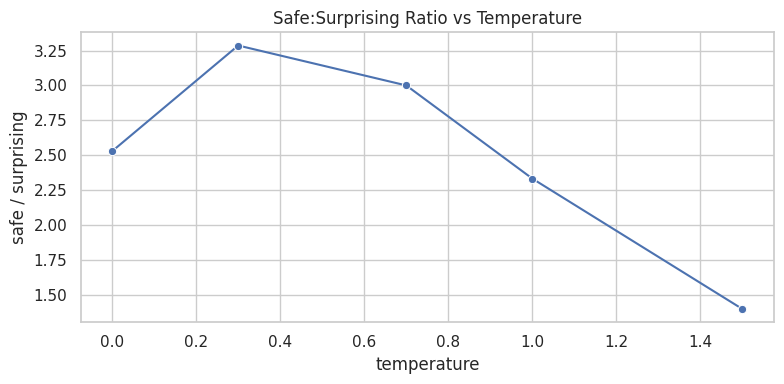

label,temperature,safe,surprising,safe_to_surprising
0,0.0,43,17,2.529412
1,0.3,46,14,3.285714
2,0.7,45,15,3.000000
3,1.0,42,18,2.333333
4,1.5,35,25,1.400000


Mode collapse analysis files saved in assignment_outputs/


In [7]:
# Problem 2, Part C: Mode collapse detection

import os
import json
from urllib import request, error

if "divergent_df" not in globals():
    divergent_df = pd.read_csv(f"{OUTPUT_FOLDER_2}/divergent_uses.csv")

# 1) Repetition test: repeat same prompt 10 times at temperature 0.7
repetition_path = Path(f"{OUTPUT_FOLDER_2}/repetition_runs_temp07.csv")


def get_openrouter_client_local():
    from openai import OpenAI

    return OpenAI(api_key=API_TOKEN, base_url=API_BASE_URL)


def get_embeddings(texts, model=None, timeout=60):
    base_url = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434").rstrip("/")
    embed_model = model or os.environ.get("OLLAMA_EMBED_MODEL", "nomic-embed-text")
    payload = {"model": embed_model, "input": texts}
    req = request.Request(
        url=f"{base_url}/api/embed",
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with request.urlopen(req, timeout=timeout) as resp:
        data = json.loads(resp.read().decode("utf-8"))
    embeddings = data.get("embeddings", [])
    if len(embeddings) != len(texts):
        raise ValueError("Ollama returned an unexpected number of embeddings.")
    return np.array(embeddings, dtype=float)


def run_repetition_test(obj="brick", n_runs=10, model=DEFAULT_MODEL, temp=0.7):
    rows = []
    prompt = f"List 20 unusual uses for a {obj}. Be creative and surprising. Return as a numbered list."

    for run_id in range(1, n_runs + 1):
        res = call_ai_raw(
            system_prompt="You are a creative but concise assistant.",
            user_message=prompt,
            model=model,
            temperature=temp,
        )
        
        uses = parse_numbered_list(res)
        for i in range(20):
            rows.append(
                {
                    "run_id": run_id,
                    "object": obj,
                    "temperature": temp,
                    "item_index": i + 1,
                    "use_text": uses[i] if i < len(uses) else "",
                }
            )
        print(f"Completed repetition run {run_id}/{n_runs}")

    return pd.DataFrame(rows)


if repetition_path.exists():
    repetition_df = pd.read_csv(repetition_path)
    print("Loaded cached repetition runs")
else:
    repetition_df = run_repetition_test(obj="brick", n_runs=10, temp=0.7)
    repetition_df.to_csv(repetition_path, index=False)

norm_text = repetition_df["use_text"].fillna("").map(normalize_text)
exact_dup_rate = 1 - (norm_text.nunique() / len(norm_text))
print(f"Exact duplicate rate: {exact_dup_rate:.3f}")

texts = repetition_df["use_text"].fillna("").tolist()
from sklearn.metrics.pairwise import cosine_similarity

try:
    emb = get_embeddings(texts)
    sim = cosine_similarity(emb)
except Exception as ollama_error:
    print(f"Ollama embeddings unavailable, falling back. Details: {ollama_error}")
    raise ollama_error
    

upper = np.triu_indices_from(sim, k=1)
similar_pairs = (sim[upper] > 0.85).mean()
print(f"Pairwise semantic-similarity>0.85 proportion: {similar_pairs:.3f}")

safe_path = Path(f"{OUTPUT_FOLDER_2}/safe_surprising_labels.csv")
if safe_path.exists():
    safe_df = pd.read_csv(safe_path)
else:
    safe_df = divergent_df[["object", "temperature", "item_index", "use_text"]].copy()
    safe_df["label"] = ""
    safe_df.to_csv(safe_path, index=False)
    raise RuntimeError(f"Please label each use as 'safe' or 'surprising' in {safe_path}, then re-run this cell.")

safe_df = pd.read_csv(safe_path)
if safe_df["label"].astype(str).str.strip().eq("").any():
    print("Please fill all labels with 'safe' or 'surprising', then re-run this cell.")
else:
    safe_df["label"] = safe_df["label"].str.strip().str.lower()
    valid = safe_df["label"].isin(["safe", "surprising"])
    if not valid.all():
        bad = safe_df.loc[~valid, "label"].unique()
        raise ValueError(f"Invalid labels found: {bad}. Use only 'safe' or 'surprising'.")

    ratio = (
        safe_df.groupby(["temperature", "label"], as_index=False)
        .size()
        .pivot(index="temperature", columns="label", values="size")
        .fillna(0)
        .reset_index()
    )
    ratio["safe_to_surprising"] = ratio.get("safe", 0) / ratio.get("surprising", 1)

    plt.figure(figsize=(8, 4))
    sns.lineplot(data=ratio, x="temperature", y="safe_to_surprising", marker="o")
    plt.title("Safe:Surprising Ratio vs Temperature")
    plt.ylabel("safe / surprising")
    plt.tight_layout()
    plt.show()

    display(ratio)
    ratio.to_csv(f"{OUTPUT_FOLDER_2}/safe_surprising_ratio_by_temp.csv", index=False)

print("Mode collapse analysis files saved in assignment_outputs/")

### Bonus: The Audience Matters (10 bonus points)

**Course connection**: Mentalising (Lecture 6) — creativity needs an audience.

Add audience context to the prompt and measure whether it changes the outputs:
> "List 20 unusual uses for a brick. Your audience is [a group of 5-year-olds / a panel of art critics / a team of engineers / a comedy club audience]."

For each audience:
1. Run at temperature 0.7
2. Score using your rubric
3. Measure how the output distribution shifts

**Analysis**: Does the model adapt its creativity to the audience? Is it doing something like mentalising — modelling what each audience would find creative? Or is it just pattern-matching on audience-associated vocabulary?

In [8]:
# Bonus: Audience-context creativity experiment

import os

audiences = [
    "a group of 5-year-olds",
    "a panel of art critics",
    "a team of engineers",
    "a comedy club audience",
]

bonus_audience_path = Path(f"{OUTPUT_FOLDER_1}/audience_experiment.csv")


def get_openrouter_client_local():
    from openai import OpenAI

    return OpenAI(api_key=API_TOKEN, base_url=API_BASE_URL)


def run_audience_experiment(object_name="brick", audiences=[], temperature=0.7, model=DEFAULT_MODEL):
    rows = []

    for audience in audiences:
        prompt = (
            f"List 20 unusual uses for a {object_name}. "
            f"Your audience is {audience}. Be creative and surprising. Return as a numbered list."
        )
        resp = call_ai_raw(
            system_prompt="You adapt creativity to the audience while staying coherent.",
            user_message=prompt,
            model=model,
            temperature=temperature,
        )

        if resp is not None:
            uses = parse_numbered_list(resp)

            for i in range(20):
                row = {
                    "object": object_name,
                    "audience": audience,
                    "temperature": temperature,
                    "item_index": i + 1,
                    "use_text": uses[i] if i < len(uses) else "",
                }

                if i == 0:
                    row["raw_response"] = resp

                rows.append(row)
            print(f"Completed audience: {audience}")
        else:
            print(f"No response for audience: {audience}")

    return pd.DataFrame(rows)


if bonus_audience_path.exists():
    audience_df = pd.read_csv(bonus_audience_path)
    print("Loaded cached audience experiment")
else:
    print("Running audience experiment...")
    audience_df = run_audience_experiment(object_name="brick", audiences=audiences, temperature=0.7)
    audience_df.to_csv(bonus_audience_path, index=False)

audience_rubric_path = Path(f"{OUTPUT_FOLDER_1}/audience_rubric_scores.csv")
if audience_rubric_path.exists():
    audience_rubric = pd.read_csv(audience_rubric_path)
else:
    audience_rubric = audience_df[["audience", "item_index", "use_text"]].copy()
    audience_rubric = audience_rubric.groupby("audience", group_keys=False).apply(lambda g: g.sample(5, random_state=7)).reset_index(drop=True)
    audience_rubric["originality"] = np.nan
    audience_rubric["feasibility"] = np.nan
    audience_rubric["humour"] = np.nan
    audience_rubric["elaboration"] = np.nan
    audience_rubric.to_csv(audience_rubric_path, index=False)

print("If doing bonus scoring, fill:", audience_rubric_path)

audience_rubric = pd.read_csv(audience_rubric_path)
if not audience_rubric[["originality", "feasibility", "humour", "elaboration"]].isna().any().any():
    aud_summary = (
        audience_rubric.groupby("audience", as_index=False)
        .agg(
            originality=("originality", "mean"),
            feasibility=("feasibility", "mean"),
            humour=("humour", "mean"),
            elaboration=("elaboration", "mean"),
        )
    )
    display(aud_summary)

    aud_long = aud_summary.melt(id_vars="audience", var_name="dimension", value_name="score")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=aud_long, x="audience", y="score", hue="dimension")
    plt.title("Audience-Conditioned Creativity Scores")
    plt.xticks(rotation=20)
    plt.ylim(1, 5)
    plt.tight_layout()
    plt.show()

def lex_div(texts):
    toks = []
    for t in texts:
        toks.extend(re.findall(r"[a-zA-Z']+", str(t).lower()))
    return (len(set(toks)) / len(toks)) if toks else np.nan

lex_by_aud = (
    audience_df.groupby("audience", as_index=False)
    .apply(lambda g: pd.Series({"lexical_diversity": lex_div(g["use_text"])}))
    .reset_index(drop=True)
)
display(lex_by_aud)
lex_by_aud.to_csv(f"{OUTPUT_FOLDER_1}/audience_lexical_diversity.csv", index=False)
print("Saved audience experiment outputs to assignment_outputs/")

Running audience experiment...
Completed audience: a group of 5-year-olds
Completed audience: a panel of art critics
Completed audience: a team of engineers
Completed audience: a comedy club audience
If doing bonus scoring, fill: part1_outputs/audience_rubric_scores.csv


,audience,lexical_diversity
0,a comedy club audience,0.580275
1,a group of 5-year-olds,0.477477
2,a panel of art critics,0.544153
3,a team of engineers,0.548944


Saved audience experiment outputs to assignment_outputs/


### 🪞 Metacognitive Reflection — Problem 2 (graded, 5 points included above)

Write 200–400 words answering these questions. **This must be in your own voice — not generated by an LLM.**

1. What was the hardest part of designing a creativity rubric? What did it teach you about the evaluation problem?
2. Did the temperature results match your predictions? What surprised you?
3. Did you find evidence of mode collapse? If yes, is this a problem — or is it the model being appropriately safe?
4. How did you use LLMs during this problem? Be specific about what you prompted for and what you had to do yourself.
5. Connect your findings to the course: if creativity is search through representation space, and temperature controls the search width, what does your data tell you about the shape of that space?

*Your reflection here (double-click to edit):*




---
## Grading Summary

| Component | Points |
|---|---|
| **Problem 1** | |
| Part A: Calibration dataset | 10 |
| Part B: Your own calibration | 10 |
| Part C: Model calibration + comparison | 15 |
| Part D: Prompt interventions | 10 |
| Bonus: Token-level probabilities | (+10) |
| **Problem 2** | |
| Part A: Divergent thinking experiment | 10 |
| Part B: Creativity rubric + metrics | 10 |
| Part C: Mode collapse detection | 15 |
| Bonus: Audience experiment | (+10) |
| **Metacognitive Reflections** | |
| Reflection 1 (included in P1) | (5 of P1) |
| Reflection 2 (included in P2) | (5 of P2) |
| **Total** | **80 + 20 bonus** |

---

### Assessment Criteria

**Code quality** (30%): Does the code run? Is it clean and documented? Are the experiments reproducible?

**Analysis quality** (40%): Are the visualisations clear? Are the comparisons meaningful? Do the analysis questions receive thoughtful, evidence-based answers that connect to course concepts?

**Metacognitive reflections** (20%): Are the reflections genuine, specific, and self-aware? Do they demonstrate learning — not just completion?

**Rigour** (10%): Sample sizes, statistical thinking, awareness of limitations. You don't need p-values, but you should know when your sample is too small to draw strong conclusions.

---

### A Note on Using LLMs

You will use LLMs both as a **tool** (to help you code) and as the **object of study** (the thing you're investigating). This is intentional. The metacognitive reflections ask you to distinguish between these two roles. The ability to use a tool critically while simultaneously studying it is a core skill for working with AI systems — and it's a form of mentalising: modelling the capabilities and limitations of a non-human agent you're interacting with.

Have fun! I am looking forward to see your results!